In [5]:
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np

import gropt

In [18]:
gparams = gropt.GroptParams()
gparams.dt = 10e-6
gparams.N = 300
gparams.vec_init_simple()

gparams.add_gmax(.2)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_moment(1,5.0)
gparams.add_moment(2,0.0)

start_t = timer()
result = gropt.solve(gparams)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}  Solve time: {1000*(stop_t-start_t):.1f} ms')

Converged: True  Solve time: 5.4 ms


In [ ]:
# time in seconds for moment calculation
t_s = tt_ms * 1e-3
dt = gparams.dt

# cumulative gradient moments M_n(t) = ∫ G(τ) τ^n dτ
m0 = np.cumsum(out) * dt
m1 = np.cumsum(out * t_s) * dt
m2 = np.cumsum(out * t_s**2) * dt
m3 = np.cumsum(out * t_s**3) * dt

fig, axs = plt.subplots(4, 1, figsize=(8, 7), sharex=True, layout="constrained", dpi=200)

axs[0].plot(tt_ms, m0)
axs[0].set_ylabel("M0 [T/m·s]")
axs[0].set_title("Gradient moments")

axs[1].plot(tt_ms, m1)
axs[1].set_ylabel("M1 [T/m·s²]")

axs[2].plot(tt_ms, m2)
axs[2].set_ylabel("M2 [T/m·s³]")

axs[3].plot(tt_ms, m3)
axs[3].set_ylabel("M3 [T/m·s⁴]")
axs[3].set_xlabel("t [ms]")

for a in axs:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.show()

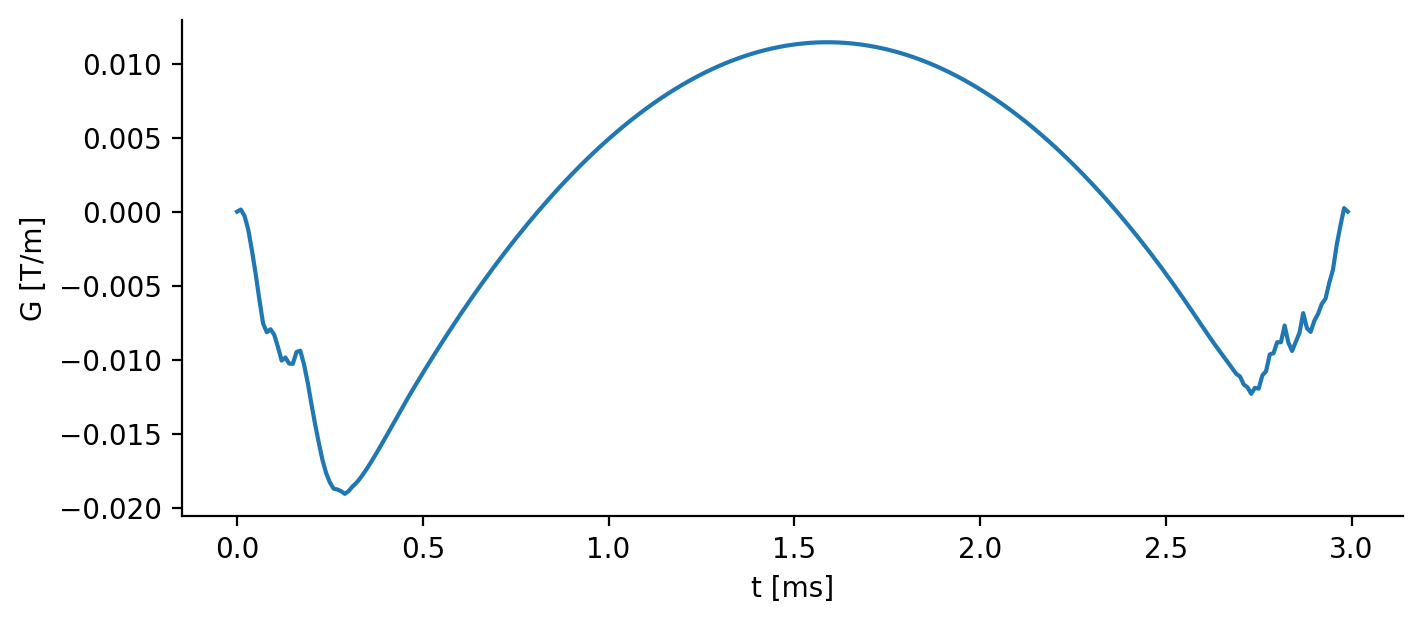

In [19]:
fig, ax = plt.subplots(figsize=(7,3), layout='constrained', dpi=200)
tt_ms = np.arange(out.size)*gparams.dt*1e3
plt.plot(tt_ms, out)
plt.xlabel('t [ms]')
plt.ylabel('G [T/m]')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
